In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline

import os
import pygmt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
import numpy as np
import pandas as pd 
import glob 
import re
import utils
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

### Model suite

Reference models with a single fault

| Dc (m)    | DX (m) | N2  |
|-------|-----|------|
| 0.01  | 20  | 4096 |
| 0.008 | 20  | 4096 |
| 0.0063 | 20  | 4096 |
| 0.005 | 10  | 8192 |
| 0.0039 | 5   | 16384 |
| 0.003 | 5   | 16384 |
| 0.002 | 5 | 16384 |
| 0.0014 | 2.5 | 32768 |
| 0.001 | 2.5   | 32768 |

In [7]:
shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a+4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000 # rate-weakening length

time_step_rate = 20
grid_step_rate_horizontal = 4 

cell_dict = {
    0.01: (20, 4096),
    0.008: (20, 4096),
    0.0063: (20, 4096),
    0.005: (10, 8192),
    0.0039: (10, 8192), 
    0.003: (5, 16384),
    0.002: (5, 16384),
    0.0014: (2.5, 32768),
    0.001: (2.5, 32768)    
} # DX and N2 info for each mdoel 

dc_map = {
    'output_Dc01': 0.01,
    'output_Dc008': 0.008,
    'output_Dc0063': 0.0063,
    'output_Dc005': 0.005,
    'output_Dc0039': 0.0039,
    'output_Dc003': 0.003,
    'output_Dc002': 0.002,
    'output_Dc0014': 0.0014,
    'output_Dc001': 0.001,
}

cols = ['Index', 'Displacement', 'Col3', 'Col4', 'Col5', 'col', 'cplb','Slip Rate', 'Col7', 'Col8', 'Col9', 'Col10','Col11'] 

### Benchmarks

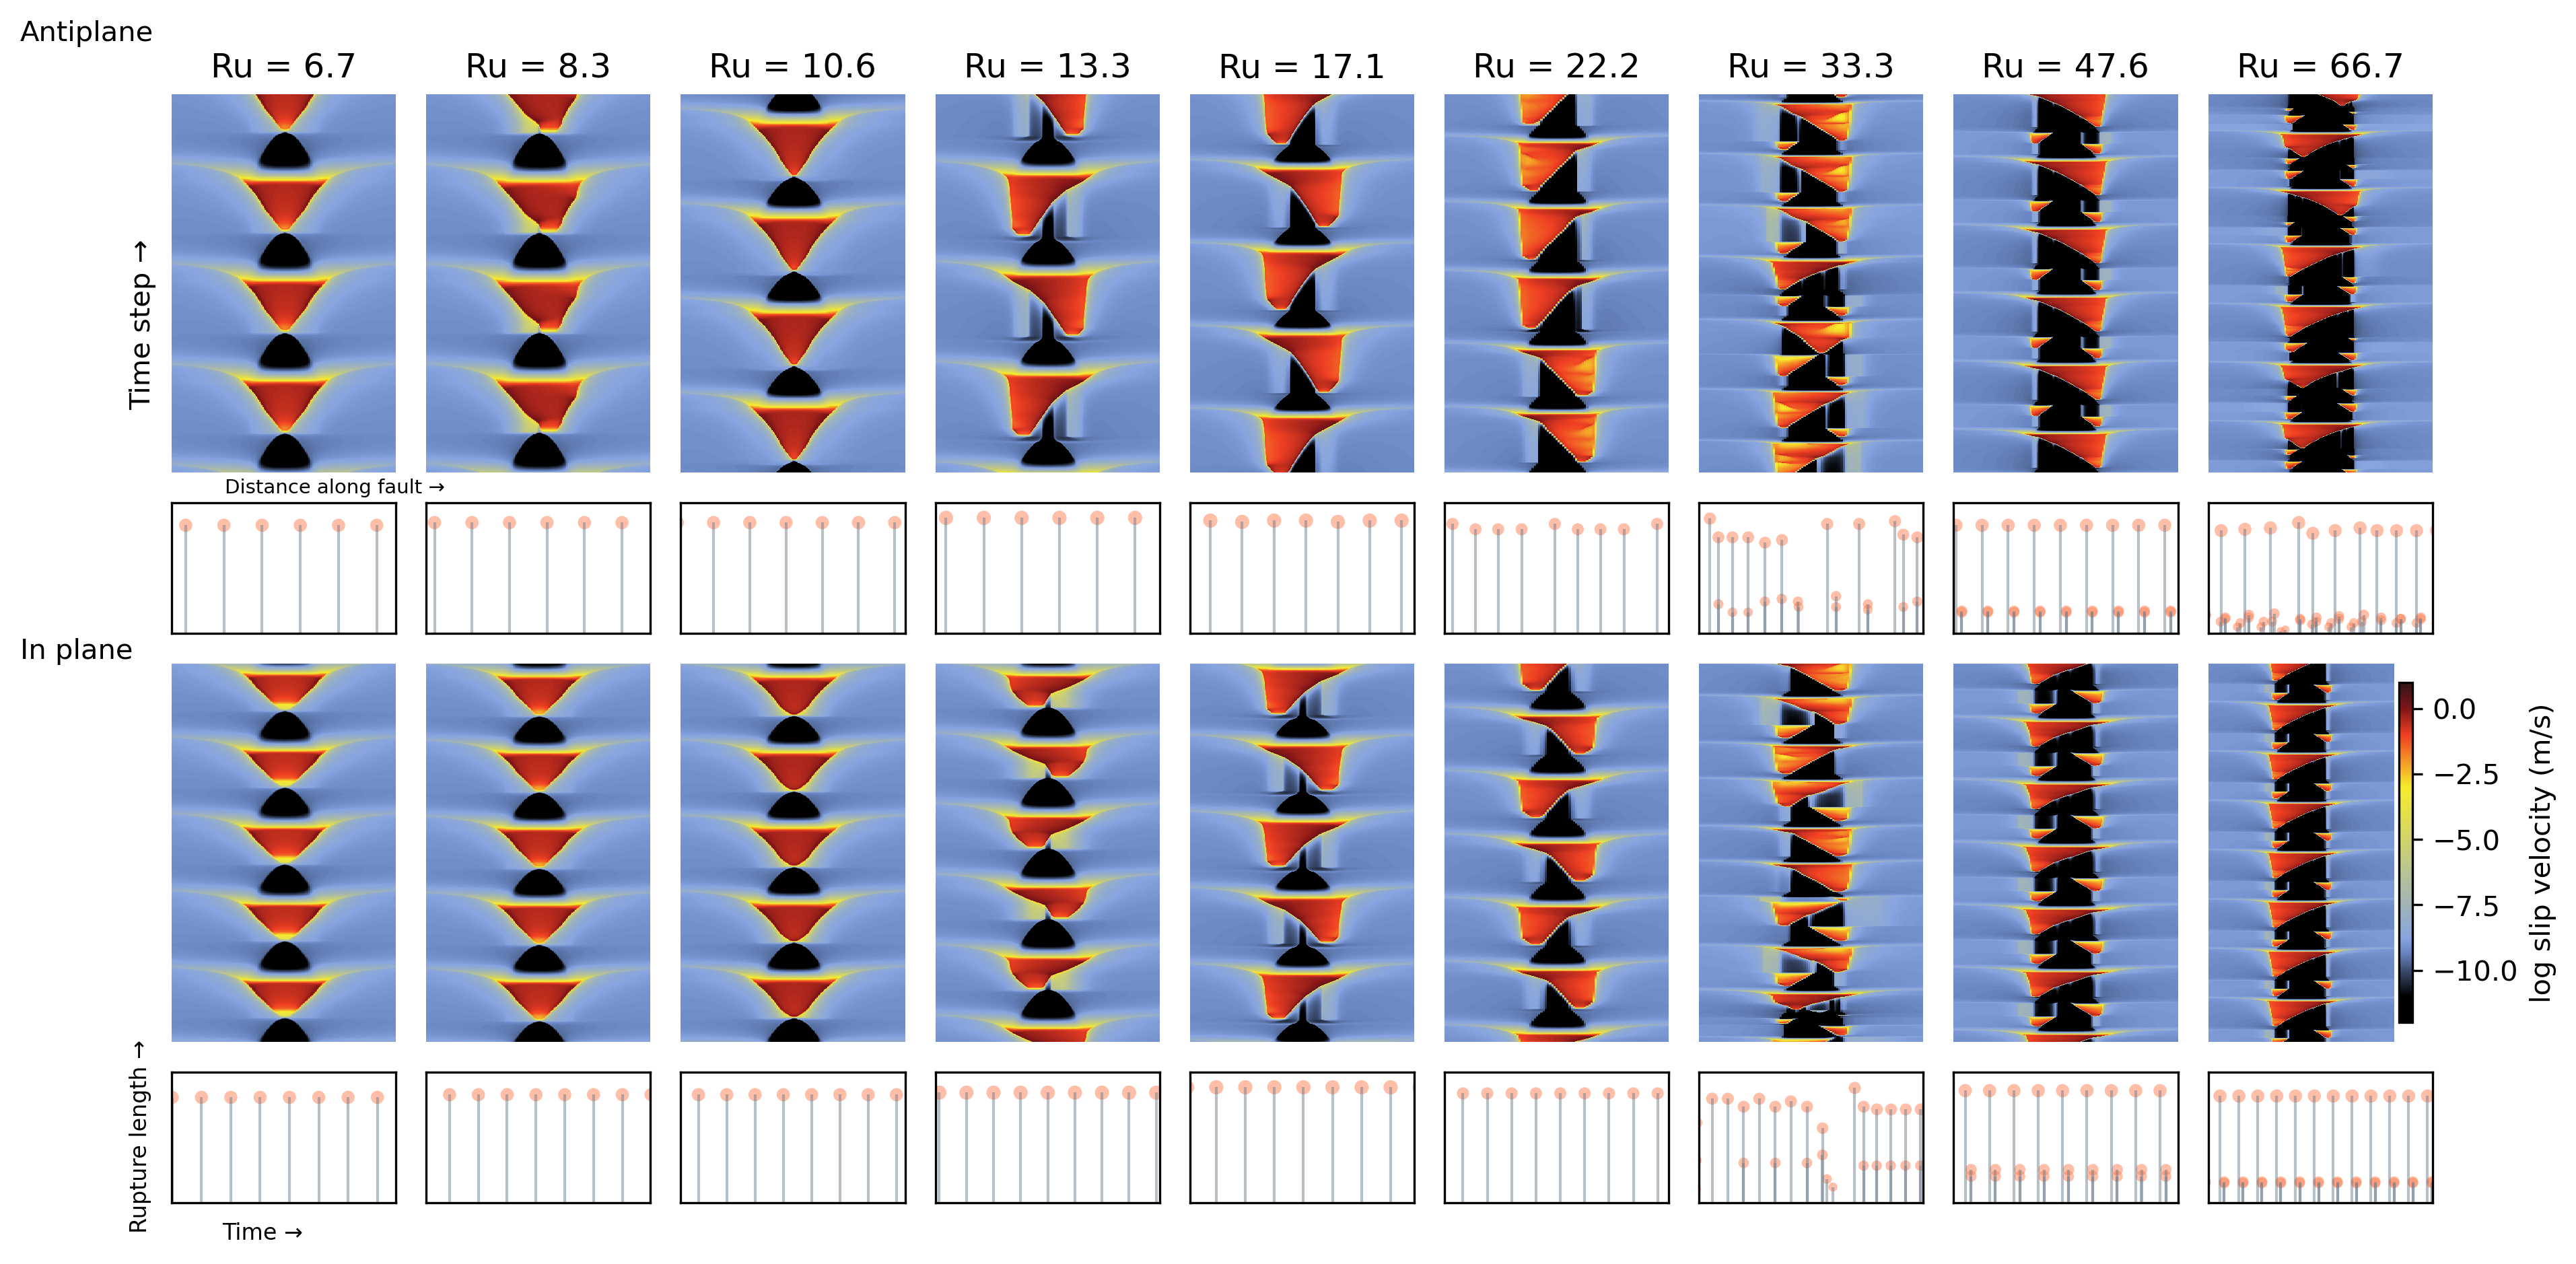

In [9]:
main_dir = 'benchmarks/single_fault_benchmark_antiplane/'
feature = 'log10v' # tau, slip, log10v
vmin = -12 # color limits
vmax = 1
m = 256  # Define the number of colors
cmap = mcolors.ListedColormap(utils.cycles_colormap(m))

fig = plt.figure(figsize=(12, 6),dpi=300)
gs = gridspec.GridSpec(6, 9, figure=fig, height_ratios=[1, 1, 0.75, 1, 1, 0.75])

files = []
for root, dirs, file_names in os.walk(main_dir):
    for file in file_names:
        if file.endswith(feature + ".grd"):
            files.append(os.path.join(root, file))

# sort files in descending order of Dc
files.sort(key=lambda x: dc_map.get(os.path.basename(os.path.dirname(x)), float('inf')), reverse=True)

for i, file_path in enumerate(files):
    ax_top = fig.add_subplot(gs[0:2, i])
    ax_bottom = fig.add_subplot(gs[2, i])
    subdir_name = os.path.basename(os.path.dirname(file_path))
    file_name = os.path.basename(file_path)
    dc = dc_map.get(subdir_name)
    Ru = utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L)
    DX, N2 = cell_dict[dc]
    file_pattern = os.path.join(os.path.dirname(file_path), 'patch-01-*.dat')
    matching_files = glob.glob(file_pattern)
    fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

    grid_data = pygmt.load_dataarray(file_path, engine='netcdf4')
    if dc <= 0.0032:
            grid_data = grid_data.coarsen(x=8, boundary='trim').mean()
        
    sns.heatmap(grid_data, ax=ax_top, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False)
    x_lim1 = int(grid_data.shape[1] * 0.4) # removing 30% of grid on both edges on x axis
    x_lim2 = int(grid_data.shape[1] * 0.6)
    ax_top.set_xlim(x_lim1, x_lim2)
    y_lim1 = int(grid_data.shape[0] * 0.35) # zooming into y axis chunk
    y_lim2 = int(grid_data.shape[0] * 0.55) # zooming into y axis chunk
    ax_top.set_ylim(y_lim1, y_lim2)

    ax_top.set_title(f'Ru = {Ru:.1f}',fontsize=12)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_bottom.set_xticks([])
    ax_bottom.set_yticks([])
    
    # catalog 
    delta_grid = time_step_rate   
    time_grid = fault_data['Index'].iloc[::int(delta_grid)].values
    grid1_masked = np.ma.masked_where(grid_data < -3.5, grid_data) 
    grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
    timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DX,N2,"No")
    time_f1 = time_grid[timestep_event_fault1]
    rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 
    
    # remove ruptures that are 4 cells only (1 cell in here because of MTC downsampling) -- artifacts from masking
    ok_size_rupture_idx1 = np.where(rupture_length_fault1 > 3)[0]
    time_f1 = time_f1[ok_size_rupture_idx1]
    rupture_length_fault1 = rupture_length_fault1[ok_size_rupture_idx1]
    
    scale_factor = 5
    ax_bottom.scatter(time_f1/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
                    c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.5, edgecolor='none')
    ax_bottom.vlines(
        x=time_f1/365/24/60/60,
        ymin=0,
        ymax=(rupture_length_fault1 * pixel_size) / 1000,
        color='slategray',
        alpha=0.5,
        linewidth=1
    )
    ax_bottom.set_xlim(400, 700)
    ax_bottom.set_ylim(0.2, 8)

main_dir = 'benchmarks/single_fault_benchmark_inplane/'
files = []
for root, dirs, file_names in os.walk(main_dir):
    for file in file_names:
        if file.endswith(feature + ".grd"):
            files.append(os.path.join(root, file))

# sort files in descending order of Dc
files.sort(key=lambda x: dc_map.get(os.path.basename(os.path.dirname(x)), float('inf')), reverse=True)

for i, file_path in enumerate(files):
    ax_top = fig.add_subplot(gs[3:5, i])
    ax_bottom = fig.add_subplot(gs[5, i])
    subdir_name = os.path.basename(os.path.dirname(file_path))
    file_name = os.path.basename(file_path)
    dc = dc_map.get(subdir_name)
    Ru = utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L)
    DX, N2 = cell_dict[dc]
    file_pattern = os.path.join(os.path.dirname(file_path), 'patch-01-*.dat')
    matching_files = glob.glob(file_pattern)
    fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

    grid_data = pygmt.load_dataarray(file_path, engine='netcdf4')
    if dc <= 0.0032:
        grid_data = grid_data.coarsen(x=8, boundary='trim').mean()

    sns.heatmap(grid_data, ax=ax_top, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False)
    x_lim1 = int(grid_data.shape[1] * 0.4) # removing 30% of grid on both edges on x axis
    x_lim2 = int(grid_data.shape[1] * 0.6)
    ax_top.set_xlim(x_lim1, x_lim2)
    y_lim1 = int(grid_data.shape[0] * 0.35) # zooming into y axis chunk
    y_lim2 = int(grid_data.shape[0] * 0.55) 
    ax_top.set_ylim(y_lim1, y_lim2)

    #ax_top.set_title(f'Ru = {Ru:.1f}')
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_bottom.set_xticks([])
    ax_bottom.set_yticks([])
    
    # catalog 
    delta_grid = time_step_rate   
    time_grid = fault_data['Index'].iloc[::int(delta_grid)].values
    grid1_masked = np.ma.masked_where(grid_data < -3.5, grid_data) 
    grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
    timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DX,N2,"No")
    time_f1 = time_grid[timestep_event_fault1]
    rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 
    
    # remove ruptures that are 4 cells only (1 cell in here because of MTC downsampling) -- artifacts from masking
    ok_size_rupture_idx1 = np.where(rupture_length_fault1 > 3)[0]
    time_f1 = time_f1[ok_size_rupture_idx1]
    rupture_length_fault1 = rupture_length_fault1[ok_size_rupture_idx1]
    
    scale_factor = 5
    ax_bottom.scatter(time_f1/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
                    c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.5, edgecolor='none')
    ax_bottom.vlines(
        x=time_f1/365/24/60/60,
        ymin=0,
        ymax=(rupture_length_fault1 * pixel_size) / 1000,
        color='slategray',
        alpha=0.5,
        linewidth=1
    )
    ax_bottom.set_xlim(400, 700)
    ax_bottom.set_ylim(0.2, 8)

cbar = fig.colorbar(ax_top.collections[0], ax=ax_top, location='right', shrink=0.9, pad=0.02, aspect=25)
cbar.set_label('log slip velocity (m/s)',fontsize=10)
plt.tight_layout()

fig.text(-0.05, 0.99, 'Antiplane', va='center', ha='left', rotation=0, fontsize=10)
fig.text(-0.05, 0.48, 'In plane', va='center', ha='left', rotation=0, fontsize=10)
fig.text(-0.005, 0.75, 'Time step →', va='center', ha='left', rotation=90, fontsize=10)
fig.text(-0.005, 0.08, 'Rupture length →', va='center', ha='left', rotation=90, fontsize=8)
fig.text(0.08, 0.615, 'Distance along fault →', va='center', ha='center', rotation=0, fontsize=7)
fig.text(0.05, 0, 'Time →', va='center', ha='center', rotation=0, fontsize=8)

plt.savefig('Figures/single_fault_benchmark.png',bbox_inches='tight')

### Single fault benchmark same format plot as two faults

In [4]:
# #### this is the only cell that needs changing before running 
# main_dir = "benchmarks/single_fault_benchmark_antiplane/"
# files_interest = ["output_Dc01/"] # can take in list
# loading_type = "Antiplane"
# dc = 0.01 # Dc in RSF
# spin_up = 200
# DX, N2 = cell_dict[dc]
# DX = [DX]
# N2 = [N2]
# cols = ['Index', 'Displacement', 'Col3', 'Col4', 'Col5', 'col', 'cplb','Slip Rate', 'Col7', 'Col8', 'Col9', 'Col10','Col11'] 
# # time step conversion
# time_step_rate = 20 # --export-netcdf-rate 20 \ ----- I am using the same in all models so this one shouldn't change..
# grid_step_rate_horizontal = 4

# feature = 'log10v' # tau, slip, log10v
# fault1_path = main_dir + "fault-01-" + feature + ".grd"

# plt.rcParams.update({'font.size': 10})
# num_files = len(files_interest)
# vmin = -12 # color limits
# vmax = 1
# cmap = plt.get_cmap('rocket')
# cropped_cmap = colors.LinearSegmentedColormap.from_list('flare_cropped', cmap(np.linspace(0, 0.9, 256)))
# m = 256  # Define the number of colors
# cmap = mcolors.ListedColormap(utils.cycles_colormap(m))

# time_step_rate = 20
# grid_step_rate_horizontal = 4 


# for i, (file, DXi, N2i) in enumerate(zip(files_interest, DX, N2)):
#     file = file
#     fig = plt.figure(figsize=(6, 8),dpi=300)
#     gs = gridspec.GridSpec(4, 4, hspace=0.5) 
#     ax1 = fig.add_subplot(gs[0:2, 1:3])
#     ax3 = fig.add_subplot(gs[2, :])  
#     ax4 = fig.add_subplot(gs[3, :]) 
    
#     # load time file for times
#     file_pattern = main_dir + file + 'patch-01-*.dat'
#     matching_files = glob.glob(file_pattern)
#     fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)


#     # load grids for moment
#     feature = 'log10v' # tau, slip, log10v
#     fault1_path = main_dir + file + "fault-01-" + feature + ".grd"
#     grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
#     delta_grid = time_step_rate   
#     time_grid = fault_data['Index'].iloc[::int(delta_grid)].values

#     if dc<=0.014:
#         grid_fault1 = grid_fault1.coarsen(x=2, boundary='trim').mean()

#     # plot grids 
#     sns.heatmap(grid_fault1, ax=ax1, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False)
#     num_rows = grid_fault1.shape[0]
#     if DXi>=10:
#         start_row = int(num_rows / 3)  
#         end_row =  int(2 * num_rows / 2.5)  
#     elif DXi<=5:
#         start_row = int(num_rows / 3.5) 
#         end_row = int(2 * num_rows / 3.5)   
#     ax1.set_ylim(start_row, end_row)

#     x_lim1 = int(grid_fault1.shape[1] * 0.4) # removing 30% of grid on both edges on x axis
#     x_lim2 = int(grid_fault1.shape[1] * 0.6)
#     ax1.set_xlim(x_lim1, x_lim2)

#     ax1.set_xticks([])
#     ax1.set_yticks([])

#     ax1.set_title(f'Single fault')
#     ax1.set_xlabel('Distance along the fault')
#     ax1.set_ylabel('Time step #')

#     cbar_ax = fig.add_axes([0.75, 0.53, 0.02, 0.35])
#     cbar = fig.colorbar(ax1.collections[0], cax=cbar_ax, location="right", shrink=0.25, aspect=25)
#     cbar.set_label("log velocity (m/s)")

#     # make catalog
#     grid1_masked = np.ma.masked_where(grid_fault1 < -3.5, grid_fault1) # subset areas where velocity>seismic slip to isolate events
#     grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
#     timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DXi,N2i,"No")
#     time_f1 = time_grid[timestep_event_fault1]
#     rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 

#     # estimate potency
#     feature = 'slip' # tau, slip, log10v
#     fault1_path = main_dir + file + "fault-01-" + feature + ".grd"
#     grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
#     time_steps_grid = grid_fault1.shape[0]
#     potency_fault1 = utils.potency(grid_fault1,DXi*grid_step_rate_horizontal)
#     potency_fault1 = np.array(potency_fault1)

#     if len(potency_fault1)!=len(time_grid):
#         time_grid = time_grid[:-1]
        
#     # remove spin-up period 
#     time_cutoff = spin_up * 365 * 24 * 60 * 60
#     cutoff_index = np.where(time_grid >= time_cutoff)[0][0]
#     time_grid = time_grid[cutoff_index:]
#     potency_fault1 = potency_fault1[cutoff_index:]
#     time_f1 = time_f1[time_f1 >= time_cutoff]
#     rupture_length_fault1 = rupture_length_fault1[len(rupture_length_fault1) - len(time_f1):]

#     # remove ruptures that are 4 cells only (1 cell in here because of MTC downsampling) -- artifacts from masking
#     ok_size_rupture_idx1 = np.where(rupture_length_fault1 > 3)[0]

#     time_f1 = time_f1[ok_size_rupture_idx1]

#     rupture_length_fault1 = rupture_length_fault1[ok_size_rupture_idx1]

#     # detrend potency using the long-term potency for each fault 
#     poly_deg = 1
#     coeffs1 = np.polyfit(time_grid, potency_fault1, poly_deg)
#     trend1 = np.polyval(coeffs1, time_grid)
#     potency_deficit_fault1 = potency_fault1 - trend1
#     ax3.plot(time_grid/365/24/60/60,-potency_deficit_fault1, label='Fault 1', color='coral',linewidth=1.5)
#     ax3.axhline(0,linestyle=':',c='black')
#     ax3.set_xlabel('Time (years)')
#     ax3.set_xlim(spin_up,800)  
#     ax3.set_ylim(-40000,40000)  
#     ax3.set_yscale('symlog', linthresh=1e2)
#     # plot catalog
#     ax4.set_ylabel('Rupture length (km)')
#     scale_factor = 20
#     ax4.scatter(time_f1/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
#                     c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.5, edgecolor='coral',label='Fault 1')
#     ax4.set_xlim(spin_up,800)
#     ax3.set_ylabel(r'Potency deficit (m$^2)$')
#     ax4.set_ylim(-1, 9)
#     ax4.set_xlabel('Time (years)')


### Benchmark rupture distribution prediction

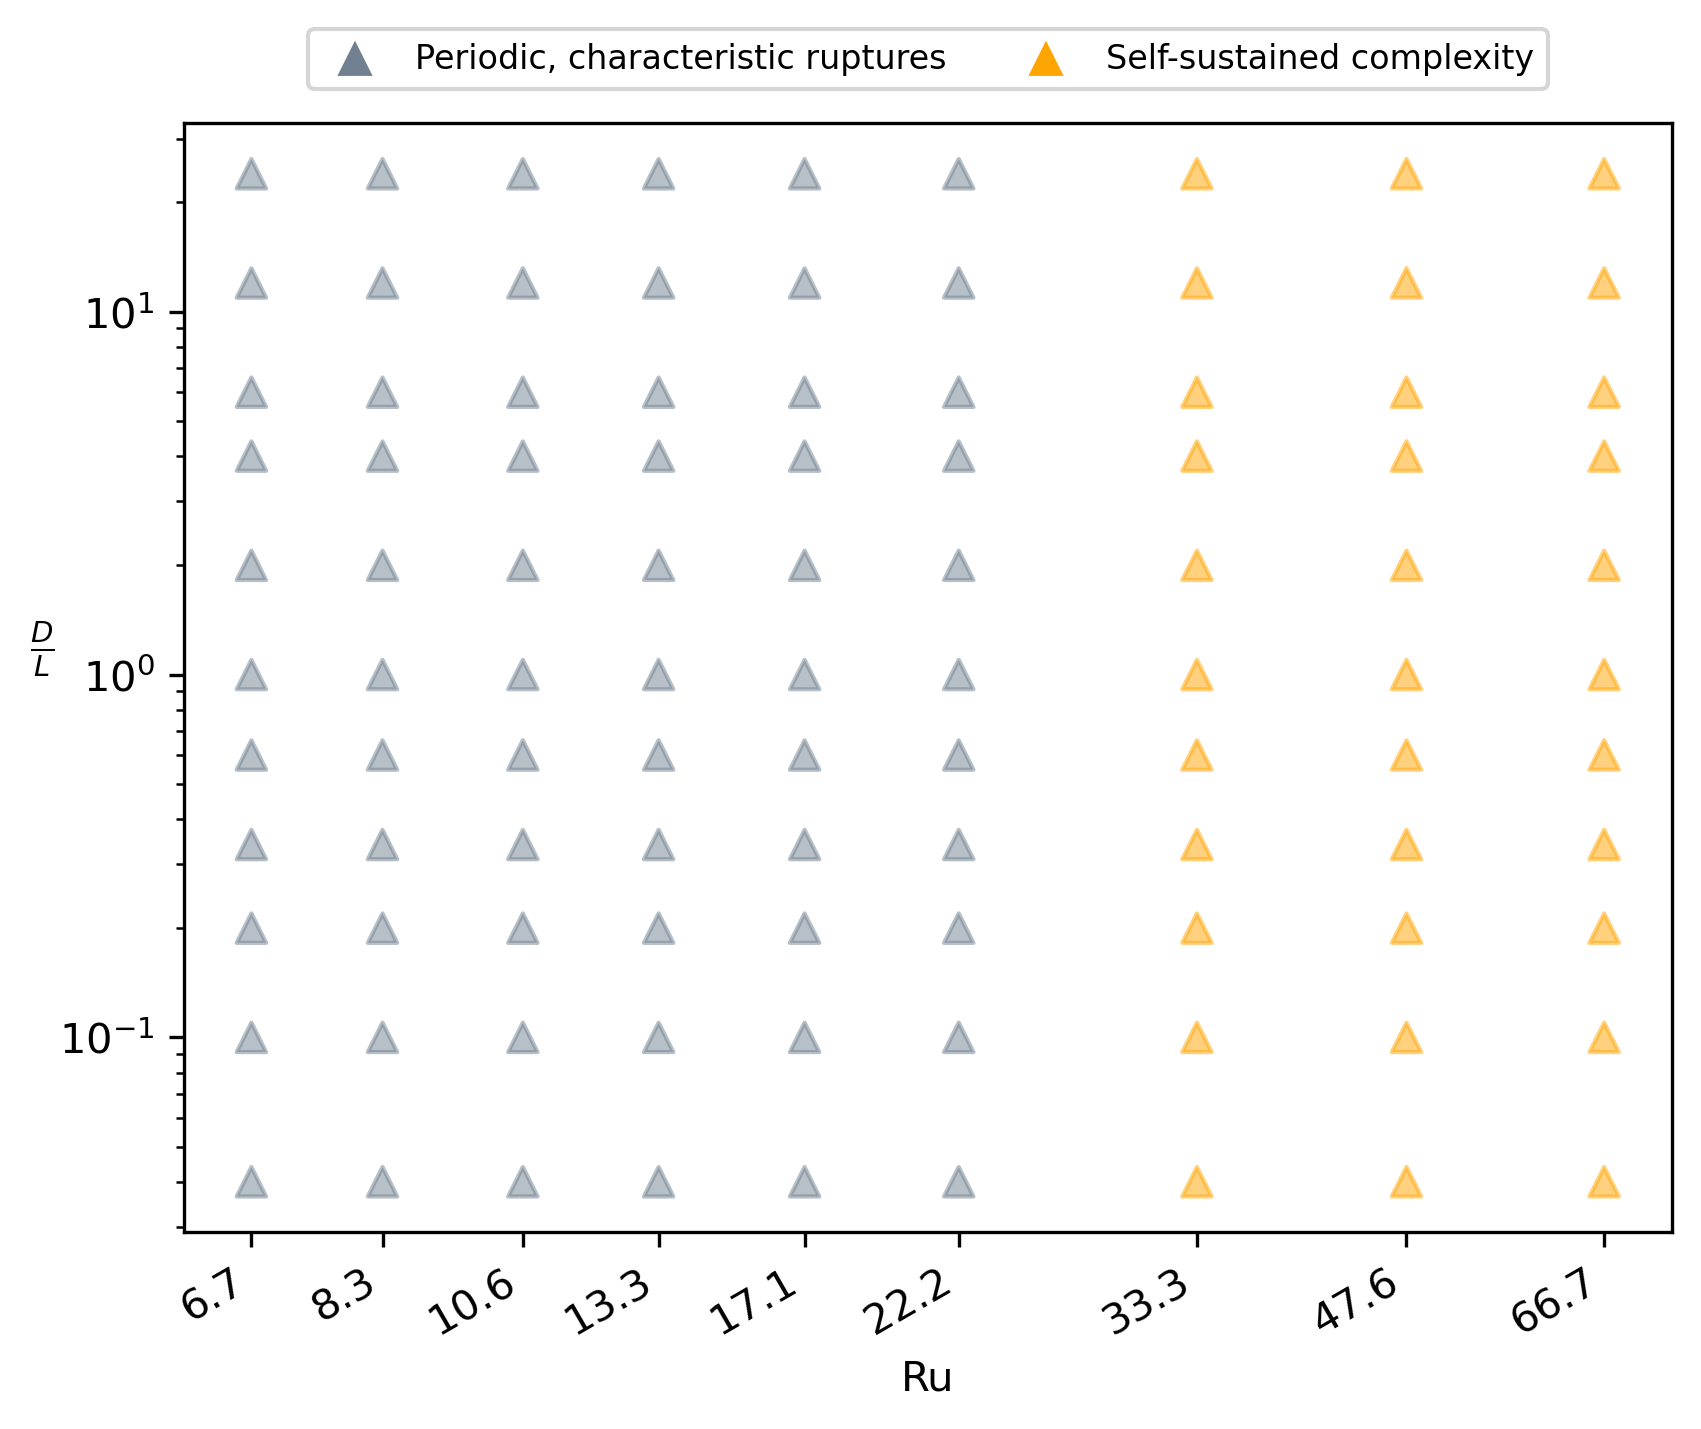

In [9]:
D_range = np.array([0.2,0.5,1,1.7,3,5,10,20,30,60,120])*10**3 # spacing
Dc = np.array([0.01, 0.008, 0.0063, 0.005, 0.0039, 0.003, 0.002, 0.0014, 0.001]) # critical slip distance
shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a+4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000 # rate-weakening length

D_W_values = np.array([utils.estimate_D_W_ratio(D, L) for D in D_range])
Ru_values = np.array([utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L) for dc in Dc])
h_star_values = np.array([utils.estimate_h_star(shear_mod, dc, b, a, sigma_o) for dc in Dc])

plt.figure(dpi=300)
D_W_matrix = np.tile(D_W_values, (len(Dc), 1))  # Make D_W a 2D matrix for easier indexing
for j in range(len(D_W_values)):  
    colors = ['slategray'] * (len(Dc) - 3) + ['orange'] * 3
    plt.scatter(Ru_values, D_W_matrix[:, j], marker='^', c=colors, s=50,alpha=0.5)  

plt.ylabel(r"$\frac{D}{L}$",rotation=0)
plt.xlabel("Ru")
plt.xscale('log')
plt.yscale('log')


legend_elements = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='slategray', markersize=10, label='Periodic, characteristic ruptures'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='orange', markersize=10, label='Self-sustained complexity')
]

plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2,fontsize=8)

desired_ticks = np.unique(Ru_values)
plt.gca().set_xticklabels([])
plt.gca().xaxis.set_minor_locator(plt.NullLocator())
plt.gca().set_xticks(desired_ticks)
plt.gca().set_xticklabels([f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha='right')

plt.savefig('Summary figures/single_fault/Ru_D_W_benchmark_expectations.png',bbox_inches='tight')

### Number of cells in process zone test

In [10]:
def process_zone_size(mu_star,L,b,sigma):
    '''Process zone size based on rate and state friction'''
    process_zone = (mu_star*L)/(b*sigma) # meters
    return process_zone

def process_zone_over_cell(process_zone,cell_size):
    '''Ratio of the process zone length to the maximum grid size'''
    return process_zone/cell_size

In [11]:
mode_II_mu_star  = shear_mod/(1-0.25)
mode_III_mu_star = shear_mod
cell_sizes = [20, 20, 10, 10, 10, 5, 5, 2.5, 2.5] # cell size per model corresponding to each value of dc

process_zone_size_II = np.array([process_zone_size(mode_II_mu_star,dc,b,sigma_o) for dc in Dc])
process_zone_size_III = np.array([process_zone_size(mode_III_mu_star,dc,b,sigma_o) for dc in Dc])
cell_density_II = np.array([process_zone_over_cell(process_zone,cell_size) for process_zone,cell_size in zip(process_zone_size_II,cell_sizes)])
cell_density_III = np.array([process_zone_over_cell(process_zone,cell_size) for process_zone,cell_size in zip(process_zone_size_III,cell_sizes)])

In [12]:
cell_density_II

array([14.28571429, 11.42857143, 18.        , 14.28571429, 11.14285714,
       17.14285714, 11.42857143, 16.        , 11.42857143])

In [13]:
cell_density_III

array([10.71428571,  8.57142857, 13.5       , 10.71428571,  8.35714286,
       12.85714286,  8.57142857, 12.        ,  8.57142857])

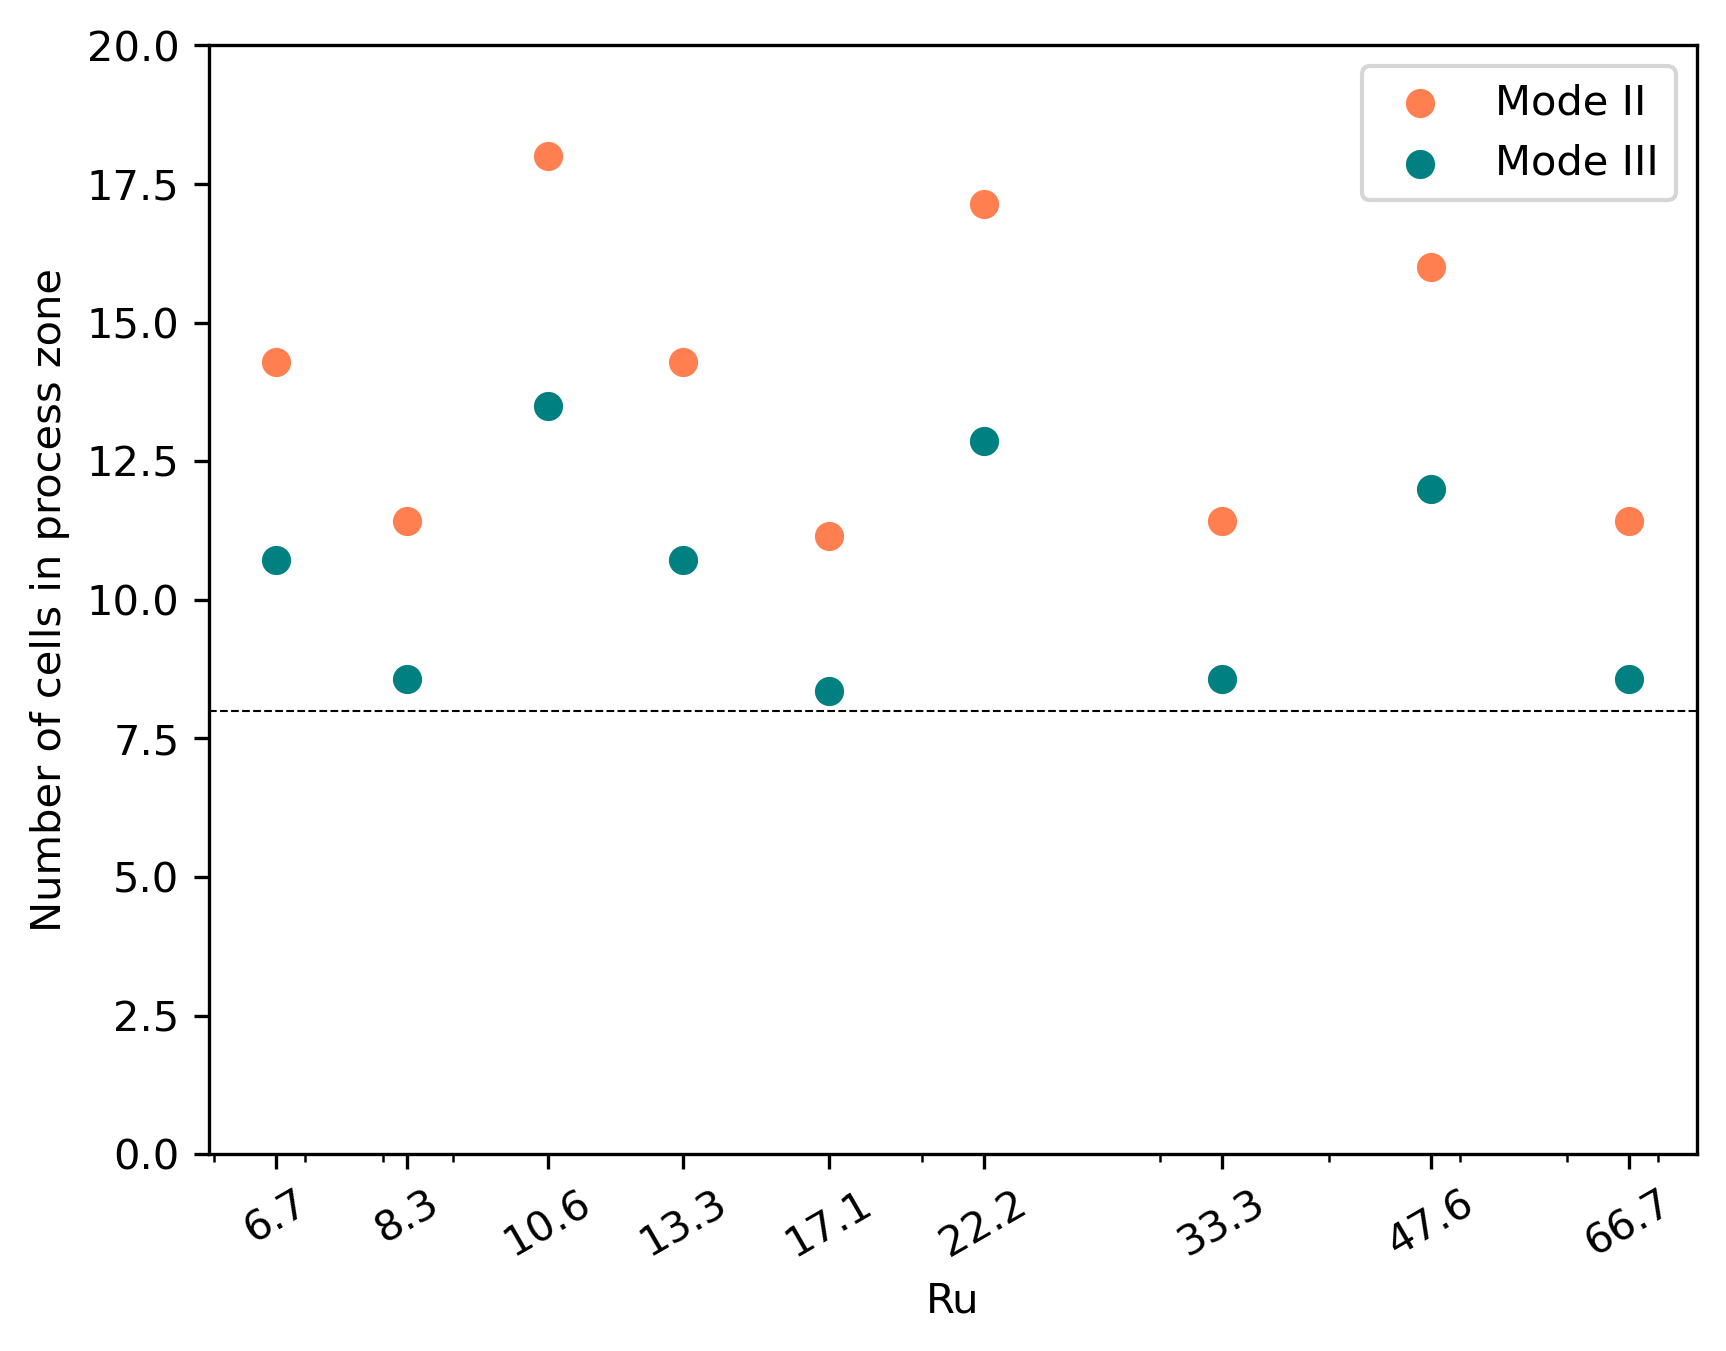

In [14]:
plt.figure(dpi=300)
plt.scatter(Ru_values,cell_density_II,c='coral',label='Mode II')
plt.scatter(Ru_values,cell_density_III,c='teal',label='Mode III')
desired_ticks = Ru_values
plt.xlabel(r"Ru")
plt.legend()
plt.xscale('log')
ax = plt.gca()
ax.set_xscale('log')
ax.set_xticks(desired_ticks)
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.tick_params(axis='x', rotation=30)
plt.ylabel("Number of cells in process zone")
plt.axhline(8, color='black', linestyle='--',lw=0.5)
plt.ylim(0,20)
plt.savefig('Summary figures/single_fault/cell_in_process_zone_benchmark.png',bbox_inches='tight')
